Nome: Cristian Javier Maza Merchan

RA: 272289

Curso:



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais: 
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação. 

In [1]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook. 

In [2]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [5]:
def read_image_url(url:str) -> np.ndarray:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

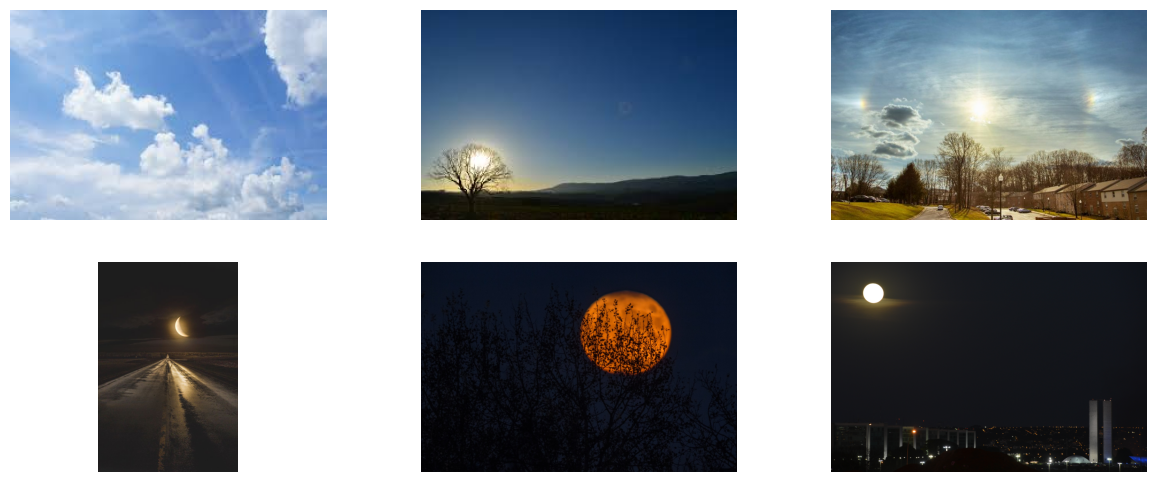

In [6]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:
  
  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))    
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

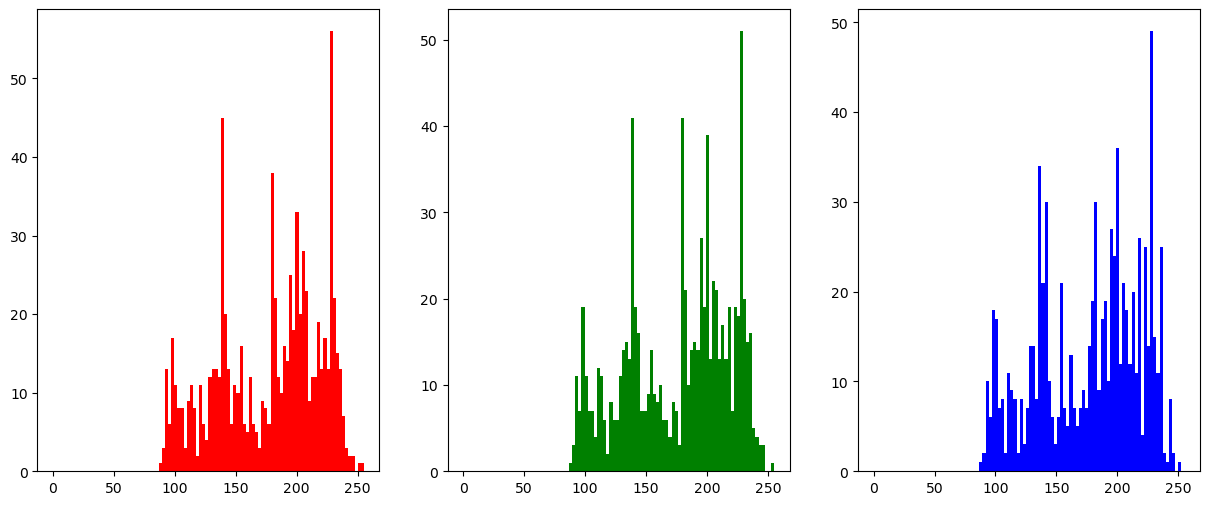

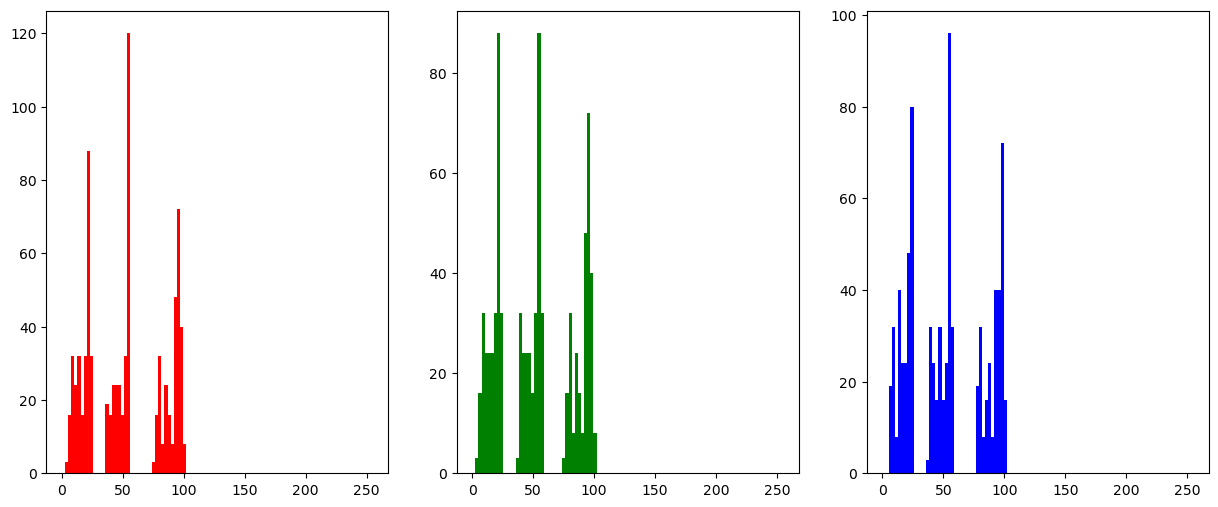

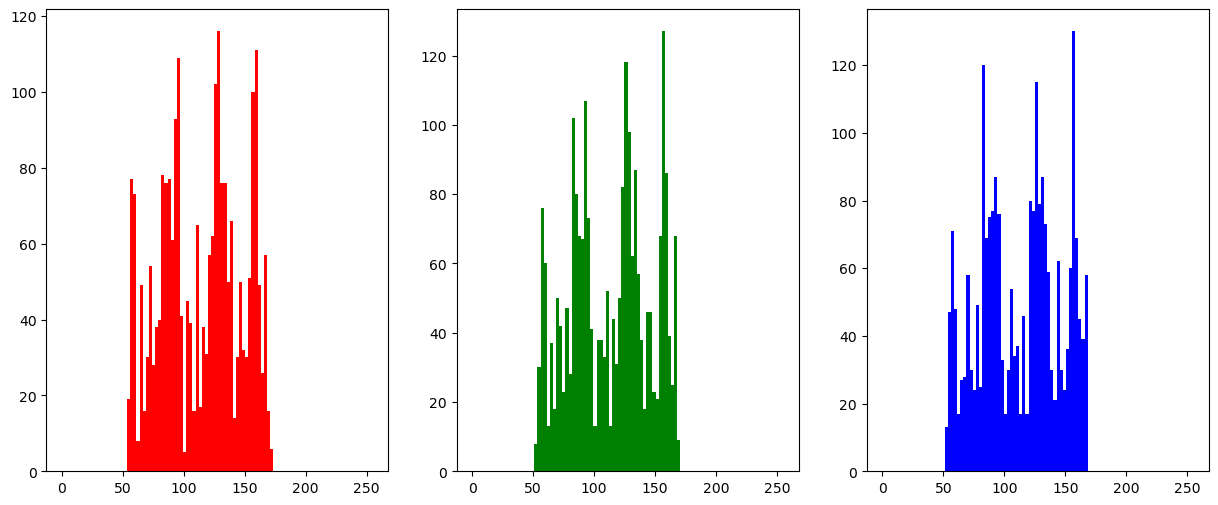

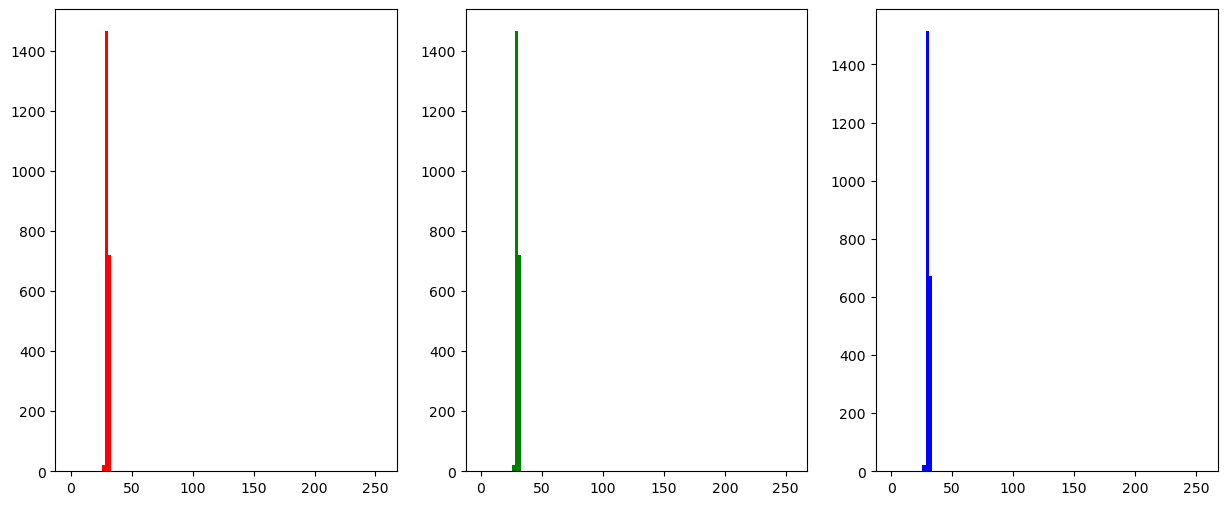

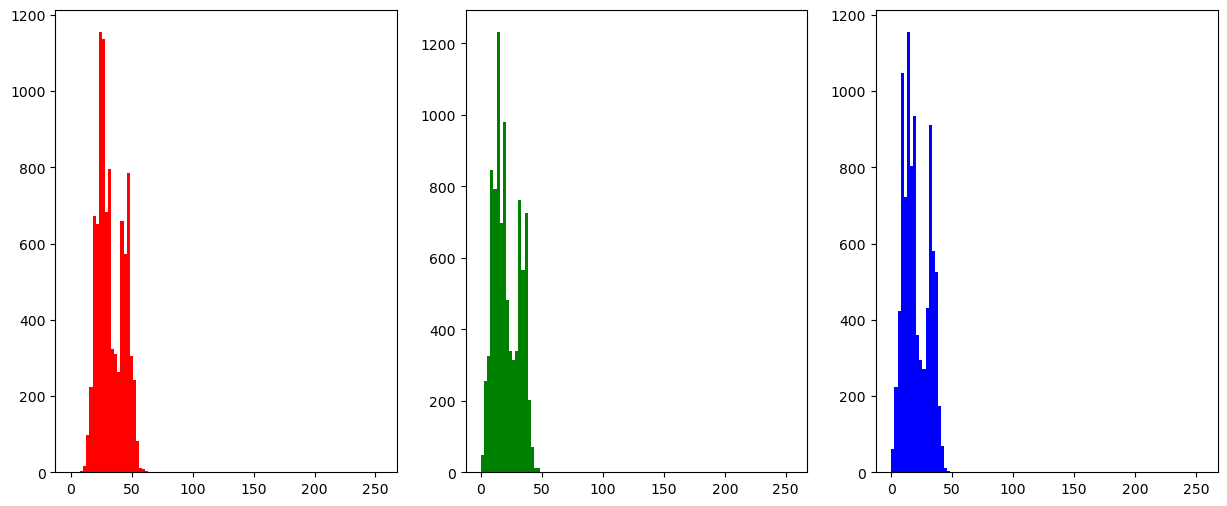

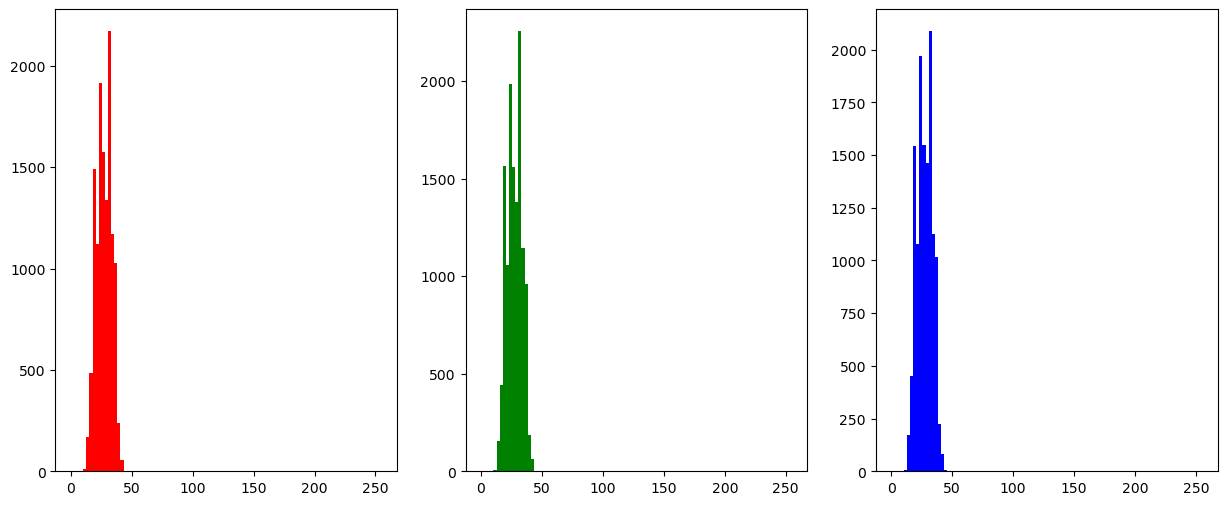

In [44]:
nbins=100
colors=["red", "green", "blue"]
for image in all_imgs:
    fig, axs = plt.subplots(1,3,figsize=(15, 6))
    for banda in range(3):
        h, bin_edges = np.histogram(image[banda], nbins,(0,255))
        cor=colors[banda]
        plt.subplot(1,3,1+banda)
        img=plota_hist(h,cor,nbins,bin_edges)
        index += 1
    plt.show(img)

# Histogram for all 3 bands look very similar for a given image
# Images with a lot of color span more values (0 to 255 in this plot)
# I could be able to guess, night images are mostly dark (low values) while day images span in a more wide range of values 

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

In [ ]:
img_dia = all_imgs[0]
img_noite = all_imgs[-1]

weights = [0.3, 0.59, 0.11] # Pesos para media ponderada: R, G, B
nbins=100

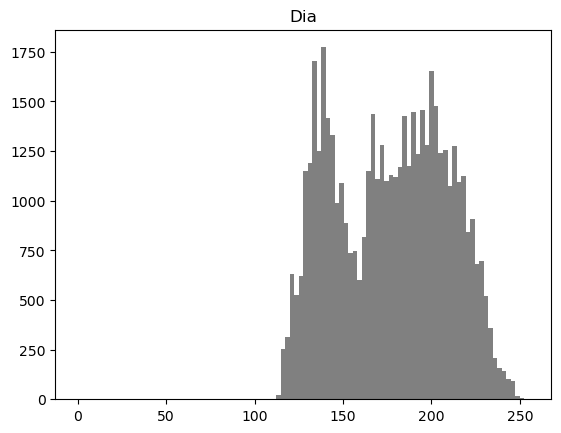

In [71]:
avg_day = np.average(img_dia, -1, weights)
h, bin_edges = np.histogram(avg_day, nbins,(0,255))
img=plota_hist(h,"gray",nbins,bin_edges)
plt.title("Dia")
plt.show(img)

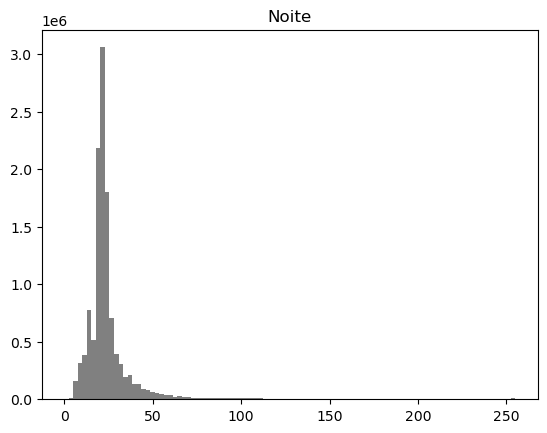

In [73]:
avg_night = np.average(img_noite, -1, weights)
h, bin_edges = np.histogram(avg_night, nbins,(0,255))
img=plota_hist(h,"gray",nbins,bin_edges)
plt.title("Noite")
plt.show(img)

## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens. 

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [3]:
def histstat(f):
    
    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

In [4]:
titles = ['mean', 'variance', 'skewness', 'kurtosis', '1% percentile', '10% percentile', '50% percentile', '90% percentile', '99% percentile']

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [10]:
f = all_imgs[0]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for idx, feature in enumerate(hist_features):
  print(f'{titles[idx]}: {feature:.2f}')

mean: 175.75
variance: 1035.83
skewness: -0.03
kurtosis: -1.11
1% percentile: 118.00
10% percentile: 132.00
50% percentile: 178.00
90% percentile: 218.00
99% percentile: 237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [ ]:
f = all_imgs[-1]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for idx, feature in enumerate(hist_features):
  print(f'{titles[idx]}: {feature:.2f}')

# They are different enough to distinguish one of each other!
# Day image has a high mean value (brighter), kurtosis is a negative low value (pixel values are more spread out)
# Night image has a lower mean value (darker), kurtosis is a higher positive value (pixel values are more concentrated around the mean)

mean: 25.47
variance: 523.00
skewness: 6.96
kurtosis: 60.49
1% percentile: 7.00
10% percentile: 13.00
50% percentile: 21.00
90% percentile: 36.00
99% percentile: 120.00


## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors) 

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN: 

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

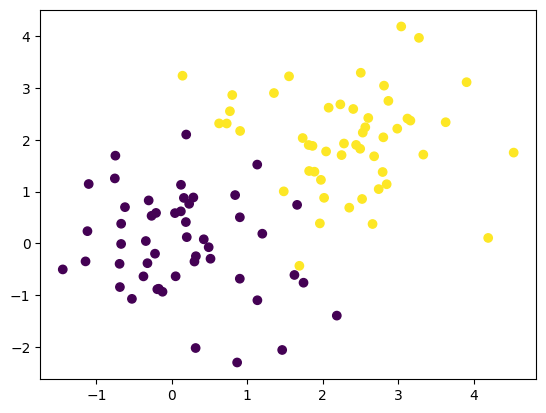

In [17]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y);

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las. 

A função *predict()* é utilizada para classificar as novas amostras.



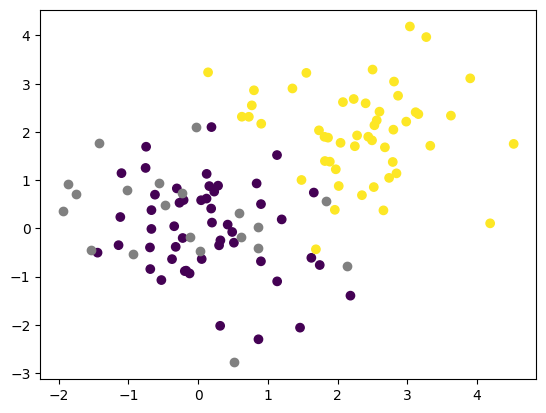

In [25]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [28]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
Precisão: 0.94
Recall: 0.98
F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


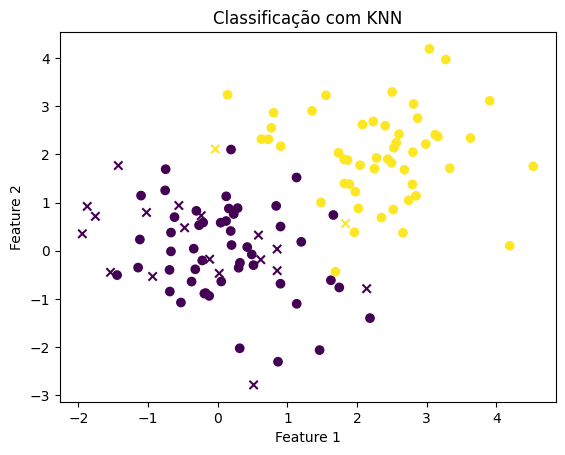

In [27]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [6]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


In [7]:
train_dataset = DermaMNIST(
    split="train",
    download=True 
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

In [8]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []
    
    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

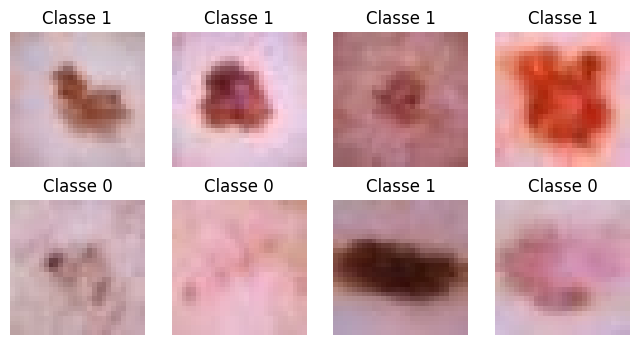

In [55]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
  plt.subplot(2,n_imgs,n+1)
  plt.axis('off')
  tmp = random.randint(0,199)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

  plt.subplot(2,n_imgs,n+n_imgs+1)
  plt.axis('off')
  tmp = random.randint(200,399)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features). 

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9. 

In [9]:
def extract_histogram_features(images):
    n_images = len(images)
    features = np.zeros((n_images, 9))
    
    weights = [0.299, 0.587, 0.114]  # Pesos para media ponderada: R, G, B
    
    for i in range(n_images):
        gray = np.average(images[i], axis=-1, weights=weights)
        hist, bin_edges = np.histogram(gray, bins=256, range=(0, 256))
        features_img = histstat(hist)
        features[i, :] = features_img
    
    return features

In [63]:
train_features = extract_histogram_features(images_train)
test_features = extract_histogram_features(images_test)

print(f'Train features shape: {train_features.shape}')
print(f'Test features shape: {test_features.shape}')

Train features shape: (400, 9)
Test features shape: (100, 9)


**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


In [64]:
# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(train_features, labels_train);

In [65]:
from sklearn.metrics import confusion_matrix

predictions = model.predict(test_features)
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(labels_test, predictions)
prec = precision_score(labels_test, predictions)
rec = recall_score(labels_test, predictions)
f1 = f1_score(labels_test, predictions)

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)


# Matriz de confusão
conf_matrix = confusion_matrix(labels_test, predictions)
print('Matriz de Confusão:')
print(conf_matrix)


Acurácia: 0.68
Precisão: 0.70
Recall: 0.62
F1-Score: 0.66
Matriz de Confusão:
[[37 13]
 [19 31]]


**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

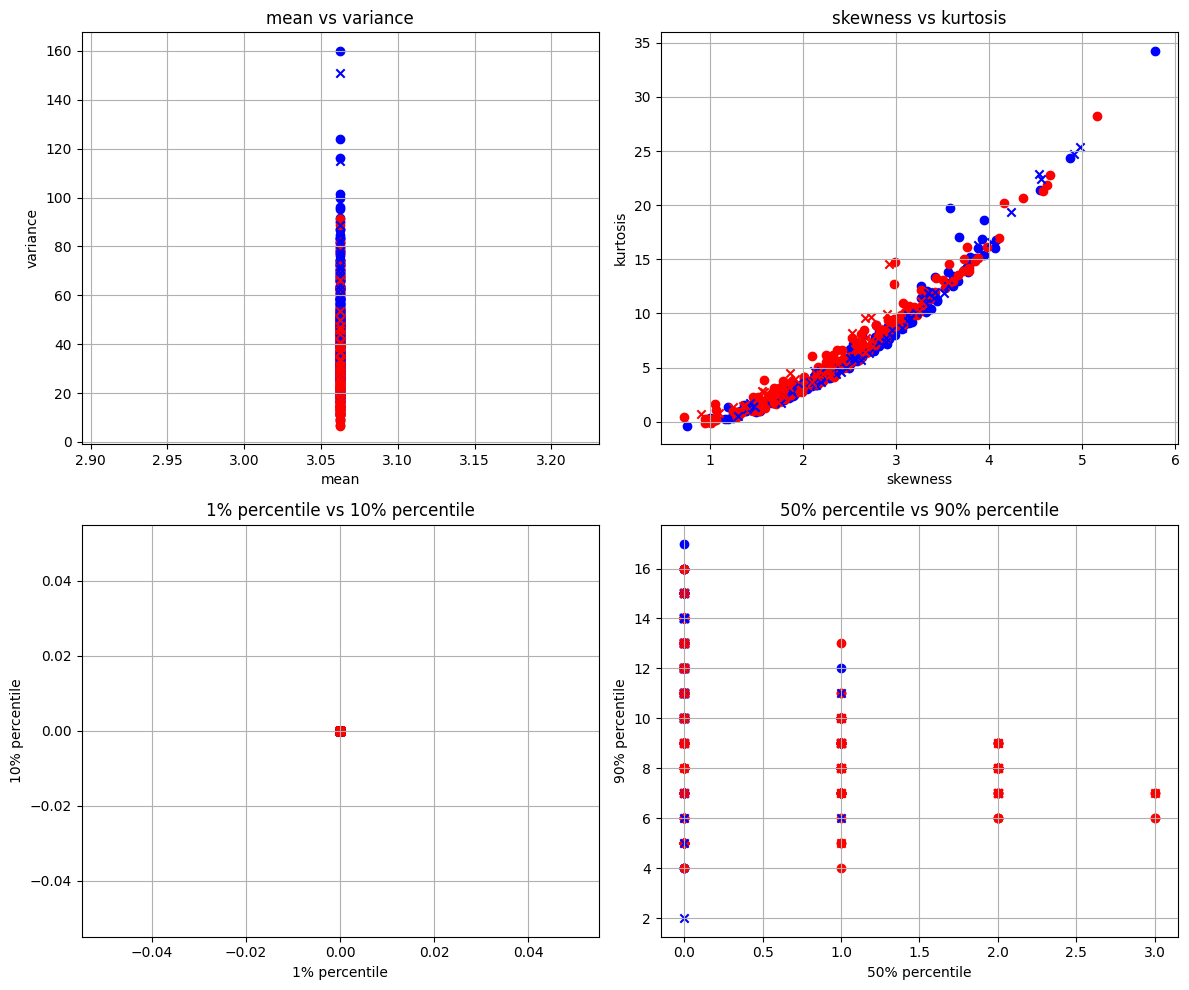

In [66]:
titles = ['mean', 'variance', 'skewness', 'kurtosis', '1% percentile', '10% percentile', '50% percentile', '90% percentile', '99% percentile']

feature_pairs = [
    (0, 1),  # mean vs variance
    (2, 3),  # skewness vs kurtosis
    (4, 5),  # 1% percentile vs 10% percentile
    (6, 7)   # 50% percentile vs 90% percentile
]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for idx, (feature_x, feature_y) in enumerate(feature_pairs):
    plt.subplot(2, 2, idx+1)
    
    # Treino - Carcinoma
    for i in range(len(labels_train)):
        if labels_train[i] == 0:
            plt.scatter(train_features[i, feature_x], train_features[i, feature_y], c='blue', marker='o')
    
    # Treino - Melanoma
    for i in range(len(labels_train)):
        if labels_train[i] == 1:
            plt.scatter(train_features[i, feature_x], train_features[i, feature_y], c='red', marker='o')
    
    # Teste - Carcinoma
    for i in range(len(predictions)):
        if predictions[i] == 0:
            plt.scatter(test_features[i, feature_x], test_features[i, feature_y], c='blue', marker='x')
    
    # Teste - Melanoma
    for i in range(len(predictions)):
        if predictions[i] == 1:
            plt.scatter(test_features[i, feature_x], test_features[i, feature_y], c='red', marker='x')
    
    plt.xlabel(titles[feature_x])
    plt.ylabel(titles[feature_y])
    plt.title(f'{titles[feature_x]} vs {titles[feature_y]}')
    plt.grid(True)

plt.tight_layout()
plt.show()

Comment:
- In figure 1 (mean vs variance): mean value is the same for all images so it's acting more like noise for the model. Variance looks better as it seems like roughly: high variance values corresponds to carcinoma and low values to melanoma.
- In figure 2 (skewness vs kurtosis): it's not clear but we can see a tendency here, we can visibily draw a curve and separate most of the samples correctly (not all) 
- In figure 3 (1% vs 10% percentile): Both features are not useful, as all classes have the same values in both metrics.
- In figure 4 (50% vs 90% percentile): Features look somewhat useful but they're not clear for easily classifying the classes.

**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

Resposta:
No. I can see some metrics are not contributing at all. 
We can remove some of the features that are not being useful for the classification in order to get better results


### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

In [ ]:
from skimage.transform import resize

def resize_images(images, new_size=(14, 14)):
    resized_images = []
    for img in images:
        img_resized = resize(img, new_size, anti_aliasing=True)
        img_resized = img_resized * 255 # Scale back to 0-255 range
        resized_images.append(img_resized)
    return resized_images

images_train_resized = resize_images(images_train, (14, 14))
images_test_resized = resize_images(images_test, (14, 14))

print(f'Imagem original: {images_train[0].shape}')
print(f'Imagem redimensionada: {images_train_resized[0].shape}')

train_features_resized = extract_histogram_features(images_train_resized)
test_features_resized = extract_histogram_features(images_test_resized)

print(f'Train features shape: {train_features_resized.shape}')
print(f'Test features shape: {test_features_resized.shape}')

Imagem original: (28, 28, 3)
Imagem redimensionada: (14, 14, 3)
Train features shape: (400, 9)
Test features shape: (100, 9)


In [ ]:
from itertools import combinations

feature_names = ['mean', 'variance', 'skewness', 'kurtosis', '1% percentile', '10% percentile', '50% percentile', '90% percentile', '99% percentile']

k_values = [7, 9, 11, 15, 20, 25]

best_accuracy = 0
best_config = {}

print("Testing combinations")

# Test different combinations of 3-8 features
for num_features in range(3, 9):
    for feature_combo in combinations(range(9), num_features):
        
        train_selected = train_features_resized[:, feature_combo]
        test_selected = test_features_resized[:, feature_combo]
        
        for k in k_values:
            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(train_selected, labels_train)
            predictions = model.predict(test_selected)
            accuracy = accuracy_score(labels_test, predictions)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_config = {
                    'features': [feature_names[i] for i in feature_combo],
                    'k': k,
                    'accuracy': accuracy
                }

print(best_config)

Testing combinations
{'features': ['variance', 'skewness', '90% percentile'], 'k': 20, 'accuracy': 0.79}


In [85]:
# Train with best combination
feature_indices = [feature_names.index(f) for f in best_config['features']]
train_final = train_features_resized[:, feature_indices]
test_final = test_features_resized[:, feature_indices]

model = KNeighborsClassifier(n_neighbors=best_config['k'])
model.fit(train_final, labels_train)
predictions = model.predict(test_final)

acc = accuracy_score(labels_test, predictions)
prec = precision_score(labels_test, predictions)
rec = recall_score(labels_test, predictions)
f1 = f1_score(labels_test, predictions)

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

conf_matrix = confusion_matrix(labels_test, predictions)
print('Matriz de Confusão:')
print(conf_matrix)

Acurácia: 0.79
Precisão: 0.84
Recall: 0.72
F1-Score: 0.77
Matriz de Confusão:
[[43  7]
 [14 36]]


## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.

In [ ]:
# Extracting histogram features from color images (RGB channels separately)
def extract_histogram_features_color(images):
    n_images = len(images)
    features = np.zeros((n_images, 27))  # 9 features per channel (R, G, B)
    
    for i in range(n_images):
        img = images[i]
        
        # Extract features for each channel
        for c in range(3):  # R, G, B
            channel = img[:, :, c]
            hist, bin_edges = np.histogram(channel, bins=256, range=(0, 256))
            features_channel = histstat(hist)
            features[i, c*9:(c+1)*9] = features_channel
    
    return features

train_features_color = extract_histogram_features_color(images_train)
test_features_color = extract_histogram_features_color(images_test)

print(f'Train features shape: {train_features_color.shape}')
print(f'Test features shape: {test_features_color.shape}')

Train features shape: (400, 27)
Test features shape: (100, 27)


In [ ]:
# Testing with basic KNN: no resize or feature selection, same scenario as our first test but now with features per channel
k = 5
model = KNeighborsClassifier(n_neighbors=k)
model.fit(train_features_color, labels_train)
predictions = model.predict(test_features_color)

acc = accuracy_score(labels_test, predictions)
prec = precision_score(labels_test, predictions)
rec = recall_score(labels_test, predictions)
f1 = f1_score(labels_test, predictions)

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

# Acurácia: 0.71
# This is already better than our grayscale experiment: Acurácia: 0.68 
# Color definitely helps

Acurácia: 0.71
Precisão: 0.71
Recall: 0.70
F1-Score: 0.71


In [ ]:
# Extracting features for each channel individually
def extract_histogram_features_single_channel(images, channel_index):
    n_images = len(images)
    features = np.zeros((n_images, 9))
    
    for i in range(n_images):
        img = images[i]
        channel = img[:, :, channel_index]
        hist, bin_edges = np.histogram(channel, bins=256, range=(0, 256))
        features_channel = histstat(hist)
        features[i, :] = features_channel
    
    return features

# Testing each channel separately
channel_names = ['Red', 'Green', 'Blue']
for c in range(3):
    train_features_channel = extract_histogram_features_single_channel(images_train, c)
    test_features_channel = extract_histogram_features_single_channel(images_test, c)
    
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(train_features_channel, labels_train)
    predictions = model.predict(test_features_channel)
    
    accuracy = accuracy_score(labels_test, predictions)
    print(f'{channel_names[c]} channel accuracy: {accuracy:.2f}')

# The Blue channel appears to produce better results. 
# Red channel accuracy: 0.72
# Green channel accuracy: 0.70
# Blue channel accuracy: 0.76

Red channel accuracy: 0.72
Green channel accuracy: 0.70
Blue channel accuracy: 0.76


In [ ]:
# Applying same improvements from Exercise 3.2: resize to (14, 14)
from skimage.transform import resize

def resize_images(images, new_size=(14, 14)):
    resized_images = []
    for img in images:
        img_resized = resize(img, new_size, anti_aliasing=True)
        img_resized = img_resized * 255
        resized_images.append(img_resized)
    return resized_images

images_train_resized_color = resize_images(images_train, (14, 14))
images_test_resized_color = resize_images(images_test, (14, 14))

train_features_color_resized = extract_histogram_features_color(images_train_resized_color)
test_features_color_resized = extract_histogram_features_color(images_test_resized_color)

print(f'Train features shape: {train_features_color_resized.shape}')
print(f'Test features shape: {test_features_color_resized.shape}')

Train features shape: (400, 27)
Test features shape: (100, 27)


In [ ]:
# Test with random feature combinations (trying to run a similar number of experiments that we did in Part 3)
from itertools import combinations

feature_names = []
for channel in ['R', 'G', 'B']:
    for stat in ['mean', 'variance', 'skewness', 'kurtosis', '1% percentile', '10% percentile', '50% percentile', '90% percentile', '99% percentile']:
        feature_names.append(f'{channel}_{stat}')

k_values = [7, 9, 11, 15, 20, 25]

best_accuracy = 0
best_config = {}

print("Testing combinations")

for num_features in range(3, 9):
    all_combos = list(combinations(range(27), num_features))
    
    # Test 115 random combinations per feature count (Roughly matching the number of experiments in Part 3)
    random.shuffle(all_combos)
    for feature_combo in all_combos[:115]:
        
        train_selected = train_features_color_resized[:, feature_combo]
        test_selected = test_features_color_resized[:, feature_combo]
        
        for k in k_values:
            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(train_selected, labels_train)
            predictions = model.predict(test_selected)
            accuracy = accuracy_score(labels_test, predictions)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_config = {
                    'features': [feature_names[i] for i in feature_combo],
                    'k': k,
                    'accuracy': accuracy
                }

print(best_config)

Testing combinations
{'features': ['R_variance', 'R_skewness', 'R_90% percentile', 'R_99% percentile', 'G_kurtosis', 'G_90% percentile', 'B_90% percentile'], 'k': 15, 'accuracy': 0.85}


In [38]:
# Train with best combination
feature_indices = [feature_names.index(f) for f in best_config['features']]
train_final = train_features_color_resized[:, feature_indices]
test_final = test_features_color_resized[:, feature_indices]

model = KNeighborsClassifier(n_neighbors=best_config['k'])
model.fit(train_final, labels_train)
predictions = model.predict(test_final)

acc = accuracy_score(labels_test, predictions)
prec = precision_score(labels_test, predictions)
rec = recall_score(labels_test, predictions)
f1 = f1_score(labels_test, predictions)

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

conf_matrix = confusion_matrix(labels_test, predictions)
print('Matriz de Confusão:')
print(conf_matrix)

Acurácia: 0.85
Precisão: 0.87
Recall: 0.82
F1-Score: 0.85
Matriz de Confusão:
[[44  6]
 [ 9 41]]


In [ ]:
# Overall, color images are better in this case. The best result we got with grayscale images was: Acurácia: 0.79
# After doing some random combinations with color features, we achieved Acurácia: 0.85
# There might even be better combinations that we haven't tried in our random testing

## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

In [39]:
# From documentation, main parameters:
# - distances: pixel pair distance (e.g., [1] means adjacent pixels)
# - angles: direction to check (e.g., [0, pi/4, pi/2, 3pi/4] for 4 directions)
# - levels: number of gray levels to use (256 for full range, or less for speed)
# Features extracted: contrast, dissimilarity, homogeneity, energy, correlation, ASM

from skimage.feature import graycomatrix, graycoprops

def extract_glcm_features(images):
    n_images = len(images)
    # 6 properties x 4 angles = 24 features
    features = np.zeros((n_images, 24))
    
    weights = [0.299, 0.587, 0.114]  # R, G, B weights
    
    for i in range(n_images):
        # Convert to grayscale
        gray = np.average(images[i], axis=-1, weights=weights)
        # Convert to uint8 and reduce levels for faster computation
        gray_uint8 = (gray / 255 * 63).astype(np.uint8)  # 64 levels instead of 256
        
        # Compute GLCM
        distances = [1]  # Distance of 1 pixel
        angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # 4 directions
        glcm = graycomatrix(gray_uint8, distances=distances, angles=angles, levels=64, symmetric=True, normed=True)
        
        # Extract properties
        contrast = graycoprops(glcm, 'contrast')[0]
        dissimilarity = graycoprops(glcm, 'dissimilarity')[0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0]
        energy = graycoprops(glcm, 'energy')[0]
        correlation = graycoprops(glcm, 'correlation')[0]
        ASM = graycoprops(glcm, 'ASM')[0]
        
        # Concatenate all features
        features[i, :] = np.concatenate([contrast, dissimilarity, homogeneity, energy, correlation, ASM])
    
    return features

# Extract GLCM features from resized train and test sets
images_train_resized = resize_images(images_train, (14, 14))
images_test_resized = resize_images(images_test, (14, 14))

train_features_glcm = extract_glcm_features(images_train_resized)
test_features_glcm = extract_glcm_features(images_test_resized)

print(f'Train features shape: {train_features_glcm.shape}')
print(f'Test features shape: {test_features_glcm.shape}')

Train features shape: (400, 24)
Test features shape: (100, 24)


In [ ]:
# Test with random feature combinations (similar scale to Part 3)
from itertools import combinations

feature_names = []
for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
    for angle in ['0°', '45°', '90°', '135°']:
        feature_names.append(f'{prop}_{angle}')

k_values = [7, 9, 11, 15, 20, 25]

best_accuracy = 0
best_config = {}

print("Testing combinations")

for num_features in range(3, 9):
    all_combos = list(combinations(range(24), num_features))
    
    # Test 115 random combinations per feature count (Roughly matching the number of experiments in Part 3 and 4)
    random.shuffle(all_combos)
    for feature_combo in all_combos[:115]:
        
        train_selected = train_features_glcm[:, feature_combo]
        test_selected = test_features_glcm[:, feature_combo]
        
        for k in k_values:
            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(train_selected, labels_train)
            predictions = model.predict(test_selected)
            accuracy = accuracy_score(labels_test, predictions)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_config = {
                    'features': [feature_names[i] for i in feature_combo],
                    'k': k,
                    'accuracy': accuracy
                }

print(best_config)

Testing combinations
{'features': ['dissimilarity_45°', 'correlation_0°', 'correlation_45°', 'correlation_135°', 'ASM_45°', 'ASM_90°'], 'k': 7, 'accuracy': 0.86}


In [42]:
# Train with best combination
feature_indices = [feature_names.index(f) for f in best_config['features']]
train_final = train_features_glcm[:, feature_indices]
test_final = test_features_glcm[:, feature_indices]

model = KNeighborsClassifier(n_neighbors=best_config['k'])
model.fit(train_final, labels_train)
predictions = model.predict(test_final)

acc = accuracy_score(labels_test, predictions)
prec = precision_score(labels_test, predictions)
rec = recall_score(labels_test, predictions)
f1 = f1_score(labels_test, predictions)

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

conf_matrix = confusion_matrix(labels_test, predictions)
print('Matriz de Confusão:')
print(conf_matrix)

Acurácia: 0.86
Precisão: 0.85
Recall: 0.88
F1-Score: 0.86
Matriz de Confusão:
[[42  8]
 [ 6 44]]


In [ ]:
# Training with 24 texture feature already shows better results than our color features
# There are more combinations that we could try, here we only tested with a distance of 1, 4 angles and 6 properties for a total of 24 features